# Events en México y sus Streams e Inventory
## Índice
1. [Descarga de Eventos Sísmicos en México](#1-eventos)

2. [Visualización de Eventos en Mapa](#2-mapa)

3. [Descarga de Streams asociados a Eventos](#3-streams)

4. [Descarga de Inventory](#4-inventory)
    
5. [Procesamiento](#5-procesamiento)


## Descarga de Eventos Sísmicos en México <a id="1-eventos"></a>

In [1]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy import read

In [2]:
client = Client("IRIS")
starttime = UTCDateTime("2013-01-01")
endtime = UTCDateTime("2023-12-31")

# Filtro por región y magnitud (México: lat -15 a 35, lon -120 a -85)
cat = client.get_events(
    starttime=starttime,
    endtime=endtime,
    minmagnitude=7,
    minlatitude=-15,
    maxlatitude=35,
    minlongitude=-120,
    maxlongitude=-85
)

print(cat)

9 Event(s) in Catalog:
2022-09-19T18:05:07.743000Z | +18.497, -102.982 | 7.6  mww
2021-09-08T01:47:47.492000Z | +16.972,  -99.743 | 7.0  mww
2020-06-23T15:29:04.329000Z | +15.883,  -96.010 | 7.4  mww
2018-02-16T23:39:39.700000Z | +16.389,  -97.979 | 7.2  mww
2017-09-19T18:14:38.430000Z | +18.568,  -98.481 | 7.1  Mww
2017-09-08T04:49:20.000000Z | +15.036,  -93.907 | 8.1  Mww
2016-11-24T18:43:48.830000Z | +11.960,  -88.835 | 7.0  mww
2014-10-14T03:51:37.110000Z | +12.589,  -88.072 | 7.3  MW
2014-04-18T14:27:24.690000Z | +17.321, -100.994 | 7.3  MW


## Visualización de Eventos en Mapa <a id="2-mapa"></a>

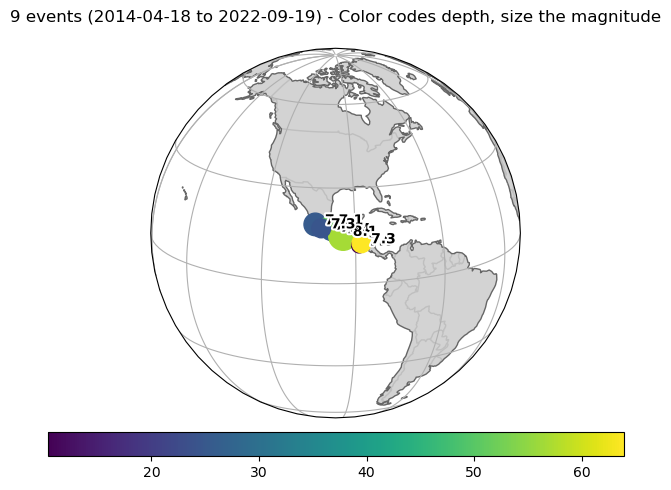

In [3]:
cat.plot(projection="ortho", resolution="l", continent_fill_color="lightgray");

## Descarga de Streams asociados a Eventos <a id="3-streams"></a>

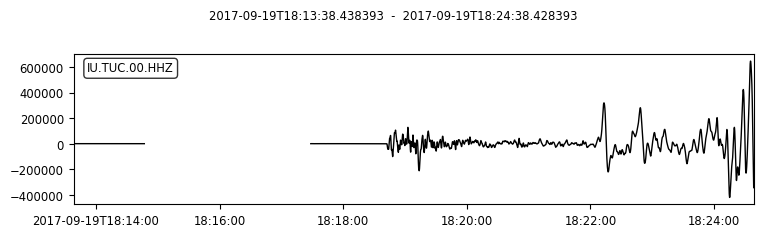

In [4]:
event = cat[4]  # Seleccionar el primer evento
origin_time = event.origins[0].time  # Tiempo de origen

# Descargar datos de la estación IU.TUC (Canales HHZ)
st = client.get_waveforms(
    network="IU",
    station="TUC",
    location="00",
    channel="HHZ",
    starttime=origin_time - 60,
    endtime=origin_time + 600,
    attach_response=True  # Para eliminar respuesta instrumental
)

st.plot();

## Descarga de Inventory <a id="4-inventory"></a>

Inventory created at 2025-04-03T00:39:52.282100Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?network=MX&station=%...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			MX
		Stations (19):
			MX.CCIG (COMITAN) (2x)
			MX.DEPC2 (Paseo de Los Grandes Lagos, Mexicali, Mexico)
			MX.HPIG (HIDALGO DEL PARRAL)
			MX.HSIG (HERMOSILLO)
			MX.MBIG (MEXICALI) (3x)
			MX.MOIG (Morelia, Mich, MX)
			MX.SJQ (Juriquilla, Queretaro, Mexico)
			MX.SPIG (SAN PEDRO MARTIR) (2x)
			MX.SRIG (SANTA ROSALIA)
			MX.TJIG (TIJUANA) (2x)
			MX.TLIG (TLAPA)
			MX.ZAIG (ZACATECAS) (3x)
		Channels (177):
			MX.CCIG..BHZ (2x), MX.CCIG..BHN (2x), MX.CCIG..BHE (2x), 
			MX.CCIG..ELZ, MX.CCIG..ELN, MX.CCIG..ELE, MX.CCIG..HHZ (2x), 
			MX.CCIG..HHN (2x), MX.CCIG..HHE (2x), MX.CCIG..HLZ (2x), 
			MX.CCIG..HLN (2x), MX.CCIG..HLE (2x), MX.DEPC2.01.HNZ, 
			MX.DEPC2.01.HNN, MX.DEPC2.01.HNE, MX.HPIG..BHZ, MX.HPIG..BHN, 
			MX.HPIG..

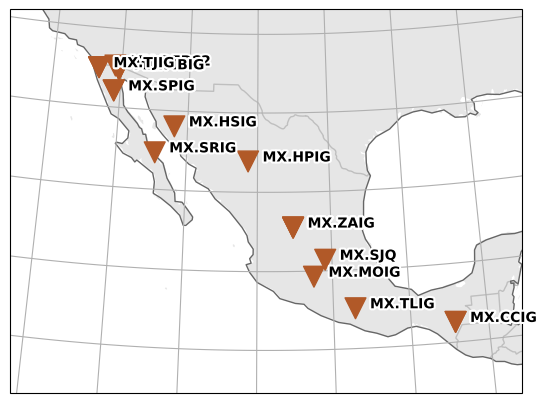

In [5]:
inv = client.get_stations(
    network="MX",
    station="*",
    level="response"  # Incluir respuesta instrumental
)

print(inv)
inv.plot(projection="local");

## Procesamiento <a id="5-procesamiento"></a>

- Eliminar respuesta instrumental usando el Inventory

- Filtrar la señal 

- Graficar señal procesada.

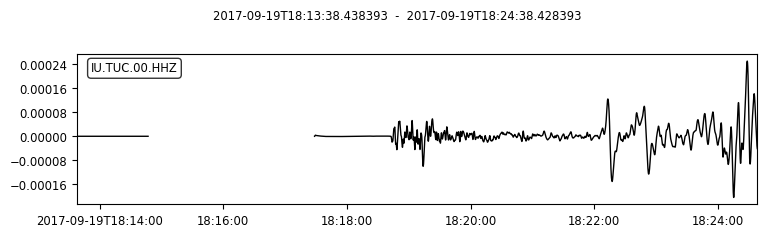

In [6]:
st_processed = st.copy()
st_processed.remove_response(output="VEL")#, inventory=inv)  # Convertir a velocidad
st_processed.filter("bandpass", freqmin=0.01, freqmax=1.0)
st_processed.plot();